In [1]:
# Section 0 — Setup, imports, constants
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import folium
from scipy import stats

# ── Path constants ─────────────────────────────────────────────────────────
BASE = r'C:/Users/mfg0631/OneDrive - AUT University/SafeSwim'
DATA    = f'{BASE}/Dataset'
EDA_DIR = f'{BASE}/EDA'
import os; os.makedirs(EDA_DIR, exist_ok=True)

LABELLED_PATH   = f'{BASE}/features_labelled.csv'
ECOLI_THRESHOLD = 540
TOP_N_CORR      = 20
TOP_N_SCATTER   = 9

SAFE_COLOUR   = '#2ecc71'
UNSAFE_COLOUR = '#e74c3c'

# ── Load gauge coordinates from metadata xlsx ──────────────────────────────
def _lookup_coord(meta_df, site_name):
    row = meta_df[meta_df['site_name'] == site_name]
    if row.empty:
        raise ValueError(f"Site not found in metadata: {site_name!r}")
    return float(row.iloc[0]['latitude']), float(row.iloc[0]['longitude'])

_swim_meta = pd.read_excel(f'{DATA}/swimspot_sites.xlsx')
_flow_meta = pd.read_excel(f'{DATA}/flow_sites.xlsx')
_rain_meta = pd.read_excel(f'{DATA}/rainfall_sites.xlsx')

GAUGE_COORDS = {
    'swim_site': {
        'name': 'Oroua at Almadale (swim site)',
        'lat': _lookup_coord(_swim_meta, 'Oroua at Almadale')[0],
        'lon': _lookup_coord(_swim_meta, 'Oroua at Almadale')[1],
        'type': 'swim',
    },
    'flow_almadale': {
        'name': 'Oroua at Almadale Slackline',
        'lat': _lookup_coord(_flow_meta, 'Oroua at Almadale Slackline')[0],
        'lon': _lookup_coord(_flow_meta, 'Oroua at Almadale Slackline')[1],
        'type': 'flow',
    },
    'rain_rangiwahia': {
        'name': 'Oroua at Rangiwahia',
        'lat': _lookup_coord(_rain_meta, 'Oroua at Rangiwahia')[0],
        'lon': _lookup_coord(_rain_meta, 'Oroua at Rangiwahia')[1],
        'type': 'rain',
    },
    'rain_cheltenham': {
        'name': 'Makino at Cheltenham',
        'lat': _lookup_coord(_rain_meta, 'Makino at Cheltenham')[0],
        'lon': _lookup_coord(_rain_meta, 'Makino at Cheltenham')[1],
        'type': 'rain',
    },
    'rain_halcombe': {
        'name': 'Makino at Halcombe Road',
        'lat': _lookup_coord(_rain_meta, 'Makino at Halcombe Road')[0],
        'lon': _lookup_coord(_rain_meta, 'Makino at Halcombe Road')[1],
        'type': 'rain',
    },
    'rain_mangaone': {
        'name': 'Mangaone at Valley Road',
        'lat': _lookup_coord(_rain_meta, 'Mangaone at Valley Road')[0],
        'lon': _lookup_coord(_rain_meta, 'Mangaone at Valley Road')[1],
        'type': 'rain',
    },
    'wt_almadale': {
        'name': 'Oroua at Almadale Slackline',
        'lat': _lookup_coord(_flow_meta, 'Oroua at Almadale Slackline')[0],
        'lon': _lookup_coord(_flow_meta, 'Oroua at Almadale Slackline')[1],
        'type': 'wt',
    },
}

# ── Load labelled dataset ──────────────────────────────────────────────────
df = pd.read_csv(LABELLED_PATH, index_col=0, parse_dates=True)
df['log10_ecoli'] = np.log10(df['ecoli_cfu'])
PREDICTORS = [c for c in df.columns if c not in ('ecoli_cfu', 'label', 'log10_ecoli')]

print(f"Loaded {len(df)} labelled rows, {len(PREDICTORS)} predictors")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Safe: {(df['label']==0).sum()}  Unsafe: {(df['label']==1).sum()}")
print(f"GAUGE_COORDS keys: {list(GAUGE_COORDS.keys())}")

Loaded 485 labelled rows, 58 predictors
Date range: 2005-07-13 → 2026-04-30
Safe: 408  Unsafe: 77
GAUGE_COORDS keys: ['swim_site', 'flow_almadale', 'rain_rangiwahia', 'rain_cheltenham', 'rain_halcombe', 'rain_mangaone', 'wt_almadale']


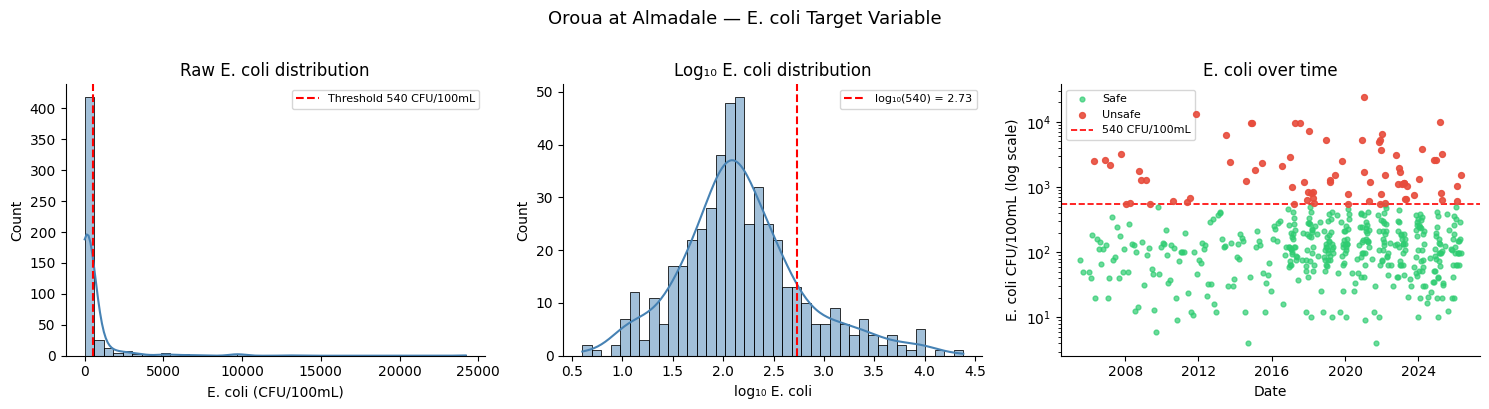

Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/EDA/eda_target_distribution.png


In [2]:
# Section 1 — Target variable distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: raw E. coli histogram
ax = axes[0]
sns.histplot(df['ecoli_cfu'], bins=40, kde=True, ax=ax, color='steelblue')
ax.axvline(ECOLI_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold {ECOLI_THRESHOLD} CFU/100mL')
ax.set_xlabel('E. coli (CFU/100mL)')
ax.set_ylabel('Count')
ax.set_title('Raw E. coli distribution')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Centre: log10 E. coli histogram
ax = axes[1]
sns.histplot(df['log10_ecoli'], bins=40, kde=True, ax=ax, color='steelblue')
log_thresh = np.log10(ECOLI_THRESHOLD)
ax.axvline(log_thresh, color='red', linestyle='--', linewidth=1.5,
           label=f'log\u2081\u2080({ECOLI_THRESHOLD}) = {log_thresh:.2f}')
ax.set_xlabel('log\u2081\u2080 E. coli')
ax.set_ylabel('Count')
ax.set_title('Log\u2081\u2080 E. coli distribution')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: time series with log y-axis
ax = axes[2]
safe_rows   = df[df['label'] == 0]
unsafe_rows = df[df['label'] == 1]
ax.scatter(safe_rows.index,   safe_rows['ecoli_cfu'],
           color=SAFE_COLOUR,   s=12, alpha=0.7, label='Safe',   zorder=5)
ax.scatter(unsafe_rows.index, unsafe_rows['ecoli_cfu'],
           color=UNSAFE_COLOUR, s=18, alpha=0.9, label='Unsafe', zorder=6)
ax.axhline(ECOLI_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
           label='540 CFU/100mL')
ax.set_yscale('log')
ax.set_xlabel('Date')
ax.set_ylabel('E. coli CFU/100mL (log scale)')
ax.set_title('E. coli over time')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Oroua at Almadale \u2014 E. coli Target Variable', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(f'{EDA_DIR}/eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {EDA_DIR}/eda_target_distribution.png")

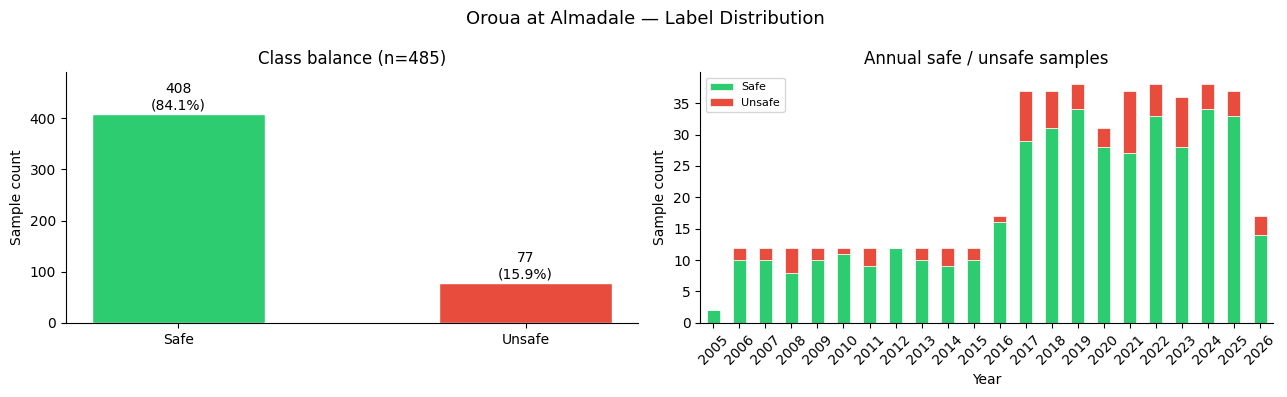

Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/EDA/eda_class_imbalance.png


In [3]:
# Section 2 — Class imbalance and label timeline
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: safe vs unsafe count bar chart
ax = axes[0]
label_names = df['label'].map({0: 'Safe', 1: 'Unsafe'})
counts = label_names.value_counts().reindex(['Safe', 'Unsafe'])
colours = [SAFE_COLOUR, UNSAFE_COLOUR]
bars = ax.bar(counts.index, counts.values, color=colours, edgecolor='white', width=0.5)
total = counts.sum()
for bar, cnt in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        f'{cnt}\n({cnt / total * 100:.1f}%)',
        ha='center', va='bottom', fontsize=10,
    )
ax.set_ylabel('Sample count')
ax.set_title(f'Class balance (n={total})')
ax.set_ylim(0, counts.max() * 1.20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: annual stacked bar chart
ax = axes[1]
df_yr = df.copy()
df_yr['year'] = df_yr.index.year
annual = (
    df_yr.groupby('year')['label']
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={0: 'Safe', 1: 'Unsafe'})
)
for col in ['Safe', 'Unsafe']:
    if col not in annual.columns:
        annual[col] = 0
annual[['Safe', 'Unsafe']].plot(
    kind='bar', stacked=True,
    color=[SAFE_COLOUR, UNSAFE_COLOUR],
    edgecolor='white', linewidth=0.5, ax=ax,
)
ax.set_xlabel('Year')
ax.set_ylabel('Sample count')
ax.set_title('Annual safe / unsafe samples')
ax.legend(loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Oroua at Almadale \u2014 Label Distribution', fontsize=13)
fig.tight_layout()
fig.savefig(f'{EDA_DIR}/eda_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {EDA_DIR}/eda_class_imbalance.png")

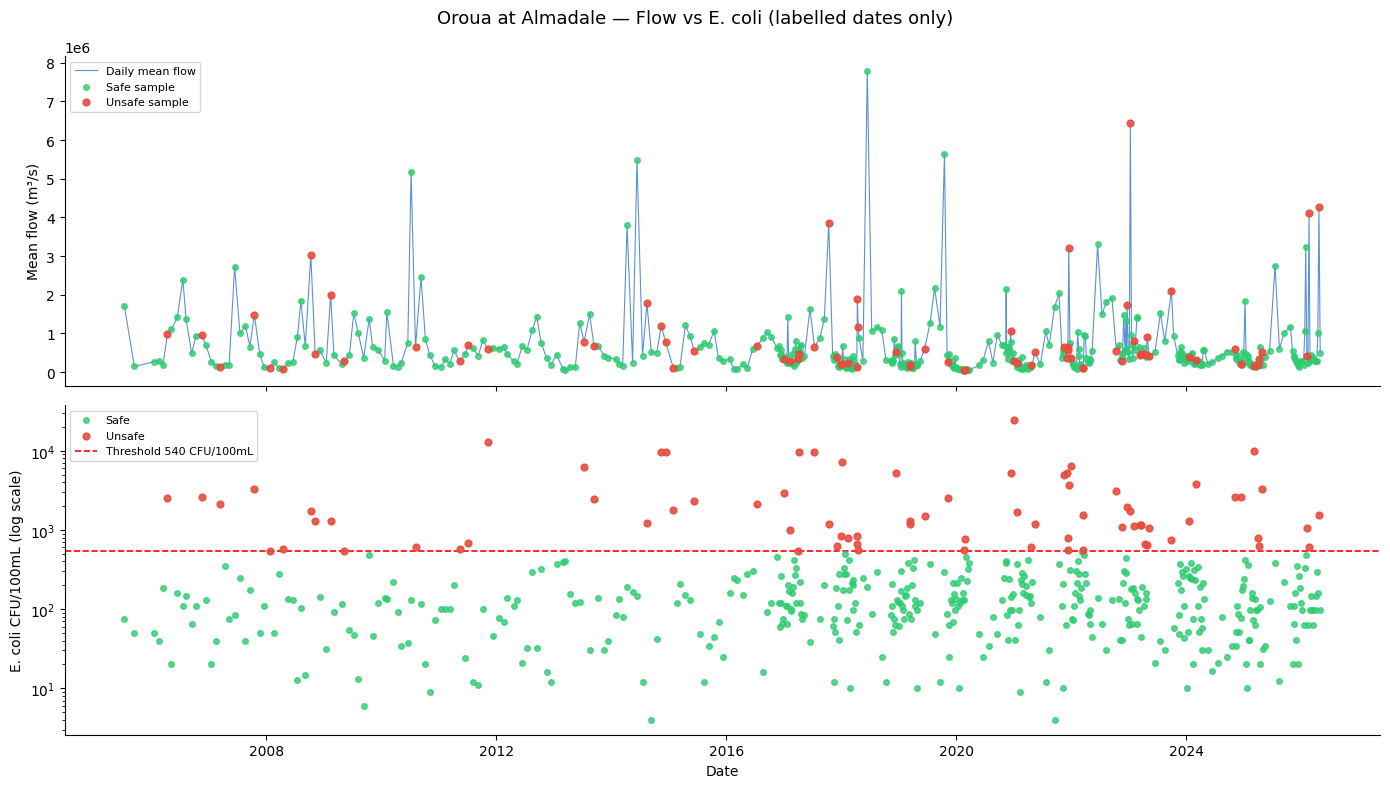

Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/EDA/eda_flow_vs_ecoli.png


In [4]:
# Section 3 — Flow vs E. coli time series (labelled dates only)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

safe_rows   = df[df['label'] == 0]
unsafe_rows = df[df['label'] == 1]

# Top panel: flow line + sample scatter
ax1 = axes[0]
ax1.plot(df.index, df['flow_almadale_mean'],
         color='#1565C0', linewidth=0.8, alpha=0.7, label='Daily mean flow')
ax1.scatter(safe_rows.index,   safe_rows['flow_almadale_mean'],
            color=SAFE_COLOUR,   s=16, zorder=5, alpha=0.8, label='Safe sample')
ax1.scatter(unsafe_rows.index, unsafe_rows['flow_almadale_mean'],
            color=UNSAFE_COLOUR, s=24, zorder=6, alpha=0.9, label='Unsafe sample')
ax1.set_ylabel('Mean flow (m³/s)')
ax1.legend(fontsize=8, loc='upper left')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Bottom panel: E. coli log scale
ax2 = axes[1]
ax2.scatter(safe_rows.index,   safe_rows['ecoli_cfu'],
            color=SAFE_COLOUR,   s=16, zorder=5, alpha=0.8, label='Safe')
ax2.scatter(unsafe_rows.index, unsafe_rows['ecoli_cfu'],
            color=UNSAFE_COLOUR, s=24, zorder=6, alpha=0.9, label='Unsafe')
ax2.axhline(ECOLI_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
            label=f'Threshold {ECOLI_THRESHOLD} CFU/100mL')
ax2.set_yscale('log')
ax2.set_ylabel('E. coli CFU/100mL (log scale)')
ax2.set_xlabel('Date')
ax2.legend(fontsize=8, loc='upper left')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Oroua at Almadale — Flow vs E. coli (labelled dates only)', fontsize=13)
fig.tight_layout()
fig.savefig(f'{EDA_DIR}/eda_flow_vs_ecoli.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {EDA_DIR}/eda_flow_vs_ecoli.png")

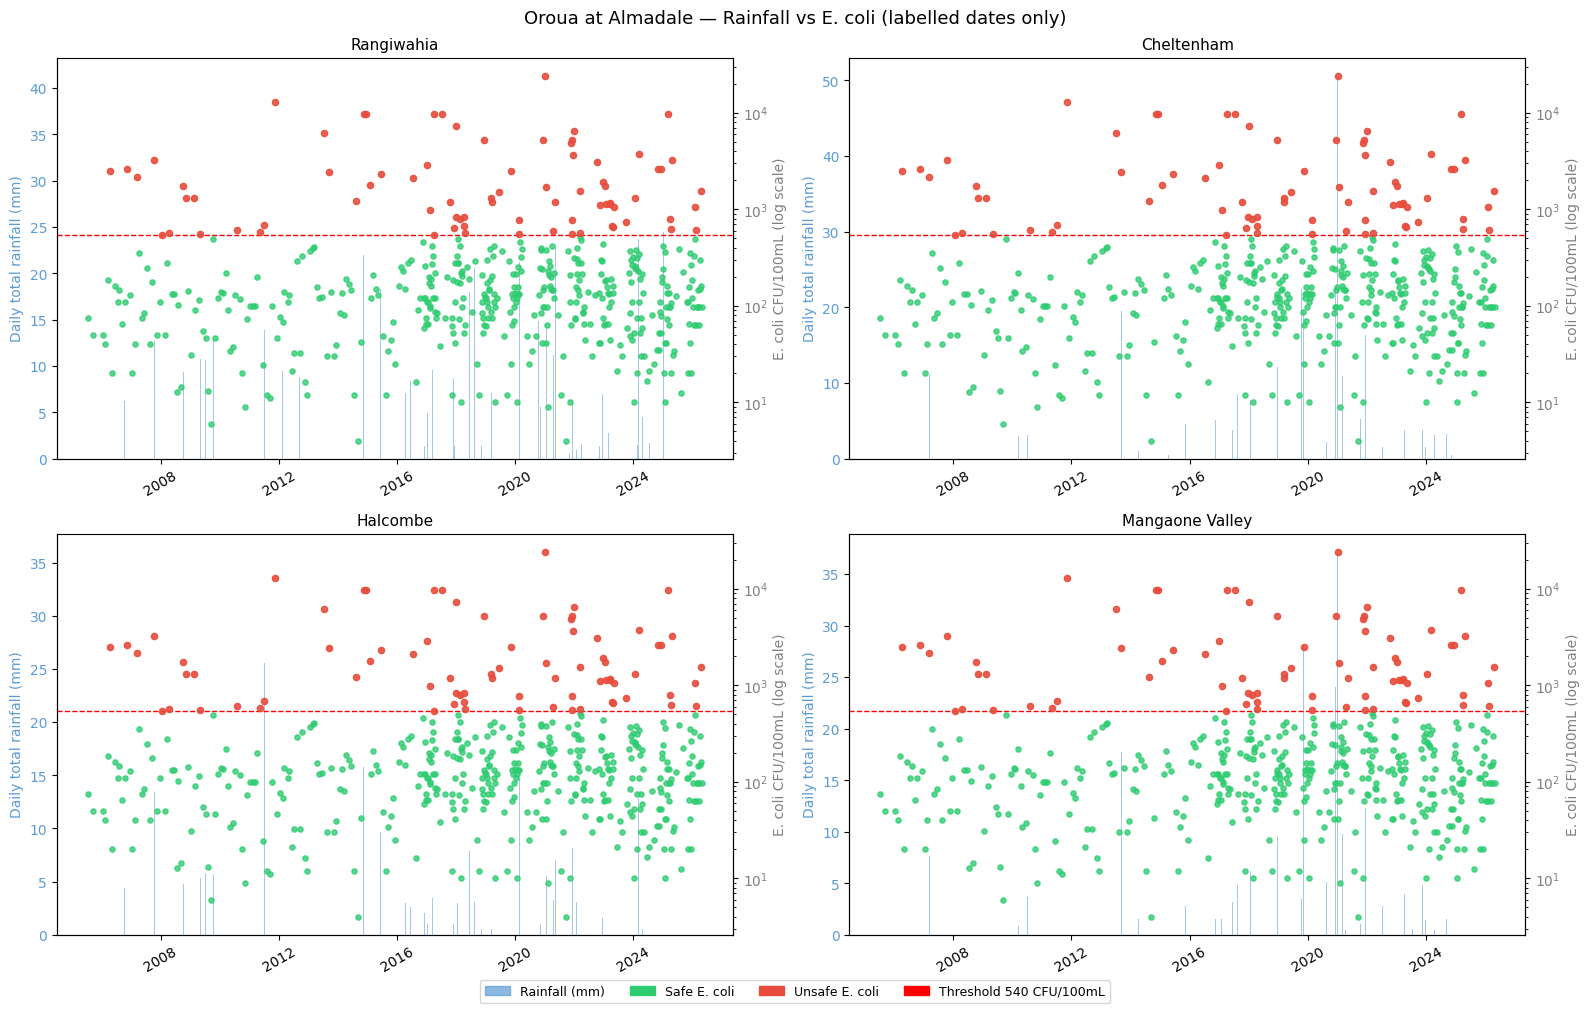

Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/EDA/eda_rainfall_vs_ecoli.png


In [5]:
# Section 4 — Rainfall vs E. coli time series (labelled dates only)
RAIN_PANELS = [
    ('rain_rangiwahia_total',      'Rangiwahia'),
    ('rain_cheltenham_total',      'Cheltenham'),
    ('rain_halcombe_total',        'Halcombe'),
    ('rain_mangaone_valley_total', 'Mangaone Valley'),
]

safe_rows   = df[df['label'] == 0]
unsafe_rows = df[df['label'] == 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, RAIN_PANELS):
    rain_vals = df[col].dropna()

    # Primary y-axis: rainfall bars
    ax.bar(rain_vals.index, rain_vals.values,
           color='#5B9BD5', alpha=0.55, width=2.0, label='Rainfall (mm)')
    ax.set_ylabel('Daily total rainfall (mm)', color='#5B9BD5')
    ax.tick_params(axis='y', labelcolor='#5B9BD5')
    ax.tick_params(axis='x', rotation=30)
    ax.spines['top'].set_visible(False)

    # Secondary y-axis: E. coli scatter
    ax2 = ax.twinx()
    ax2.scatter(safe_rows.index,   safe_rows['ecoli_cfu'],
                color=SAFE_COLOUR,   s=14, alpha=0.8, zorder=5)
    ax2.scatter(unsafe_rows.index, unsafe_rows['ecoli_cfu'],
                color=UNSAFE_COLOUR, s=20, alpha=0.9, zorder=6)
    ax2.axhline(ECOLI_THRESHOLD, color='red', linestyle='--', linewidth=1.0)
    ax2.set_yscale('log')
    ax2.set_ylabel('E. coli CFU/100mL (log scale)', color='grey')
    ax2.tick_params(axis='y', labelcolor='grey')

    ax.set_title(title, fontsize=11)

# Figure-level legend
legend_handles = [
    mpatches.Patch(color='#5B9BD5', alpha=0.7, label='Rainfall (mm)'),
    mpatches.Patch(color=SAFE_COLOUR,   label='Safe E. coli'),
    mpatches.Patch(color=UNSAFE_COLOUR, label='Unsafe E. coli'),
    mpatches.Patch(color='red',         label=f'Threshold {ECOLI_THRESHOLD} CFU/100mL'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Oroua at Almadale — Rainfall vs E. coli (labelled dates only)', fontsize=13)
fig.tight_layout()
fig.savefig(f'{EDA_DIR}/eda_rainfall_vs_ecoli.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {EDA_DIR}/eda_rainfall_vs_ecoli.png")

## Section 4b — Water Temperature vs E. coli

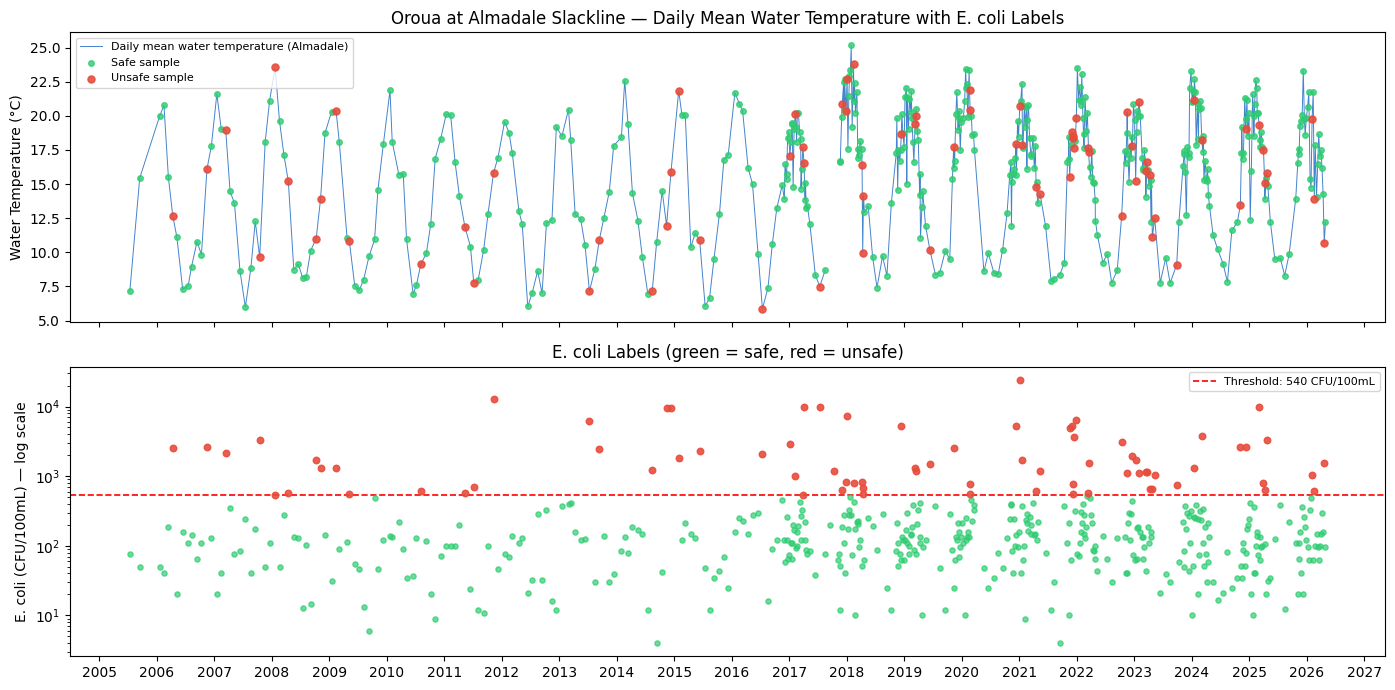

Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/EDA/eda_wt_vs_ecoli.png


In [6]:
# Section 4b — Water Temperature vs E. coli time series
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

wt_series = df['wt_almadale_mean']

ax1 = axes[0]
ax1.plot(wt_series.index, wt_series.values, color='#1565C0', linewidth=0.7, alpha=0.8,
         label='Daily mean water temperature (Almadale)')

safe_wt   = df.loc[df['label'] == 0, 'wt_almadale_mean']
unsafe_wt = df.loc[df['label'] == 1, 'wt_almadale_mean']
ax1.scatter(safe_wt.index,   safe_wt.values,   color=SAFE_COLOUR,   s=16, zorder=5, alpha=0.8, label='Safe sample')
ax1.scatter(unsafe_wt.index, unsafe_wt.values, color=UNSAFE_COLOUR, s=26, zorder=6, alpha=0.9, label='Unsafe sample')

ax1.set_ylabel('Water Temperature (°C)')
ax1.set_title('Oroua at Almadale Slackline — Daily Mean Water Temperature with E. coli Labels')
ax1.legend(fontsize=8, loc='upper left')

ax2 = axes[1]
safe_ecoli   = df.loc[df['label'] == 0, 'ecoli_cfu']
unsafe_ecoli = df.loc[df['label'] == 1, 'ecoli_cfu']
ax2.scatter(safe_ecoli.index,   safe_ecoli.values,   color=SAFE_COLOUR,   s=14, zorder=5, alpha=0.7)
ax2.scatter(unsafe_ecoli.index, unsafe_ecoli.values, color=UNSAFE_COLOUR, s=22, zorder=6, alpha=0.9)
ax2.axhline(ECOLI_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
            label=f'Threshold: {ECOLI_THRESHOLD:.0f} CFU/100mL')
ax2.set_yscale('log')
ax2.set_ylabel('E. coli (CFU/100mL) — log scale')
ax2.set_title('E. coli Labels (green = safe, red = unsafe)')
ax2.legend(fontsize=8, loc='best')

import matplotlib.dates as mdates
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_wt_vs_ecoli.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {EDA_DIR}/eda_wt_vs_ecoli.png")


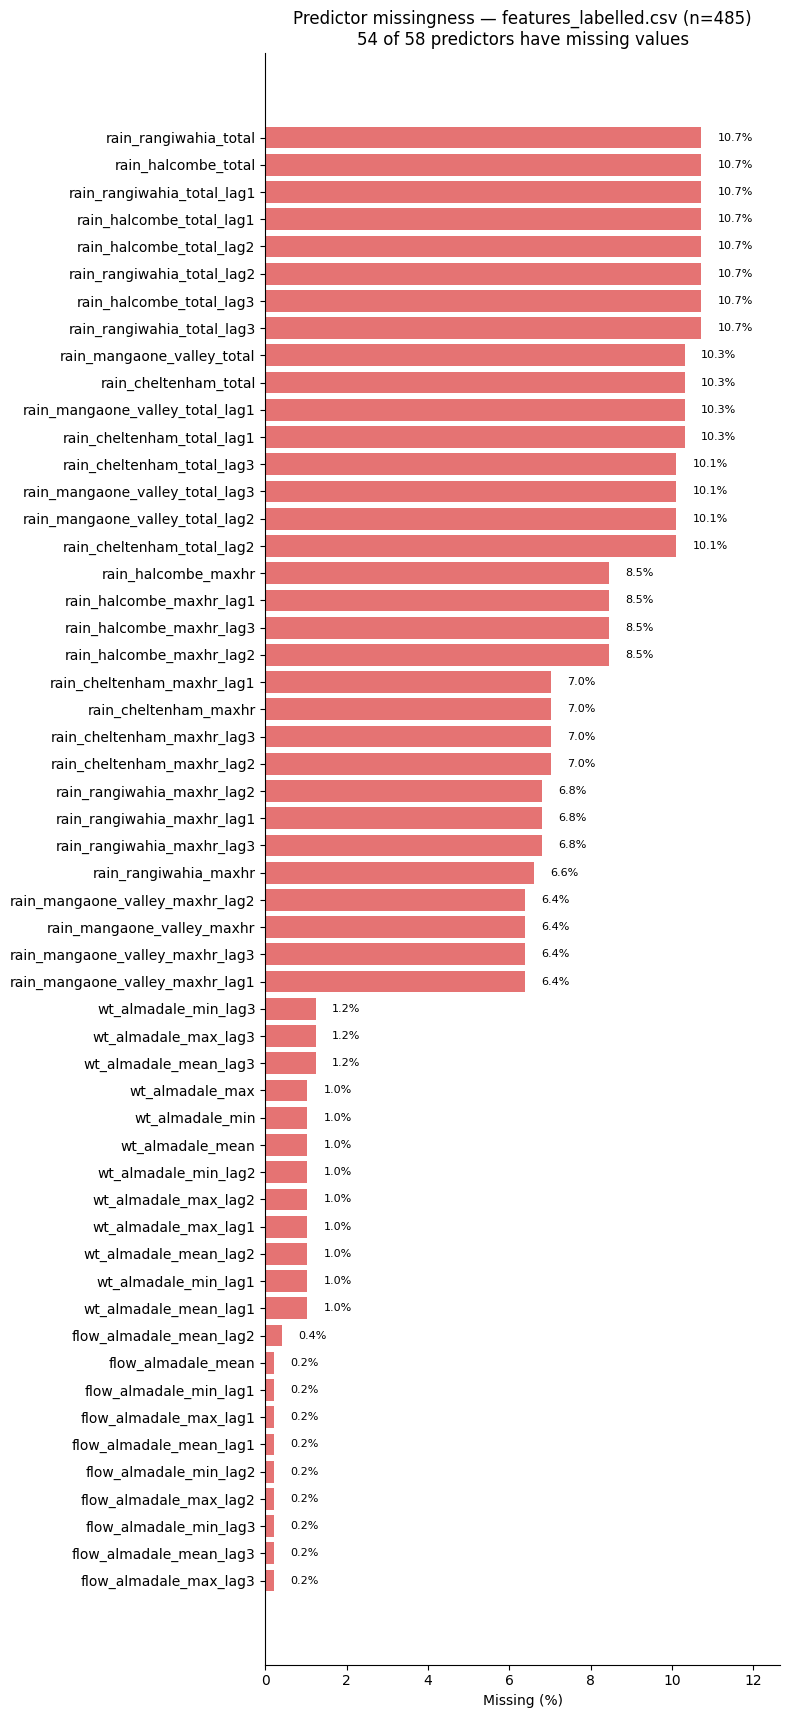

Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/EDA/eda_missingness.png


In [7]:
# Section 5 — Missingness audit
miss_pct = df[PREDICTORS].isna().mean() * 100
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=False)

if miss_pct.empty:
    print('No missing values in any predictor column — skipping plot.')
else:
    fig, ax = plt.subplots(figsize=(8, max(4, len(miss_pct) * 0.32)))
    bars = ax.barh(miss_pct.index[::-1], miss_pct.values[::-1], color='#E57373')
    for bar, pct in zip(bars, miss_pct.values[::-1]):
        ax.text(
            bar.get_width() + 0.4,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%',
            va='center', fontsize=8,
        )
    ax.set_xlabel('Missing (%)')
    ax.set_xlim(0, miss_pct.max() * 1.18)
    ax.set_title(
        f'Predictor missingness — features_labelled.csv (n={len(df)})\n'
        f'{len(miss_pct)} of {len(PREDICTORS)} predictors have missing values'
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()
    fig.savefig(f'{EDA_DIR}/eda_missingness.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {EDA_DIR}/eda_missingness.png')


In [8]:
# Section 6 — Spearman + Pearson correlation computation
records = []
for col in PREDICTORS:
    pair = df[[col, 'ecoli_cfu', 'log10_ecoli']].dropna()
    if len(pair) < 10:
        continue
    sp_raw, sp_p_raw = stats.spearmanr(pair[col], pair['ecoli_cfu'])
    sp_log, sp_p_log = stats.spearmanr(pair[col], pair['log10_ecoli'])
    pe_raw, pe_p_raw = stats.pearsonr(pair[col],  pair['ecoli_cfu'])
    pe_log, pe_p_log = stats.pearsonr(pair[col],  pair['log10_ecoli'])
    records.append({
        'predictor': col,
        'sp_raw':    sp_raw,  'sp_p_raw': sp_p_raw,
        'sp_log':    sp_log,  'sp_p_log': sp_p_log,
        'pe_raw':    pe_raw,  'pe_p_raw': pe_p_raw,
        'pe_log':    pe_log,  'pe_p_log': pe_p_log,
        'n':         len(pair),
    })

corr_df = (
    pd.DataFrame(records)
    .set_index('predictor')
    .sort_values('sp_log', key=abs, ascending=False)
)

print(f"Correlation table: {len(corr_df)} predictors")
print(corr_df[['sp_log', 'sp_raw', 'pe_log', 'pe_raw', 'n']].head(10).to_string())

Correlation table: 58 predictors
                                   sp_log    sp_raw    pe_log    pe_raw    n
predictor                                                                   
rain_rangiwahia_maxhr_lag1       0.432232  0.432232  0.529904  0.494554  452
rain_rangiwahia_total            0.429130  0.429130  0.569200  0.513130  433
rain_mangaone_valley_total       0.423106  0.423106  0.527606  0.581434  435
rain_cheltenham_total            0.407891  0.407891  0.550020  0.671437  435
rain_mangaone_valley_maxhr_lag1  0.402944  0.402944  0.470768  0.452521  454
rain_cheltenham_maxhr_lag1       0.397366  0.397366  0.442320  0.454261  451
rain_halcombe_total              0.386845  0.386845  0.522425  0.546875  433
rain_mangaone_valley_maxhr       0.371903  0.371903  0.308248  0.205134  454
rain_cheltenham_maxhr            0.361609  0.361609  0.355719  0.282778  451
rain_halcombe_maxhr_lag1         0.355144  0.355144  0.453245  0.418420  444


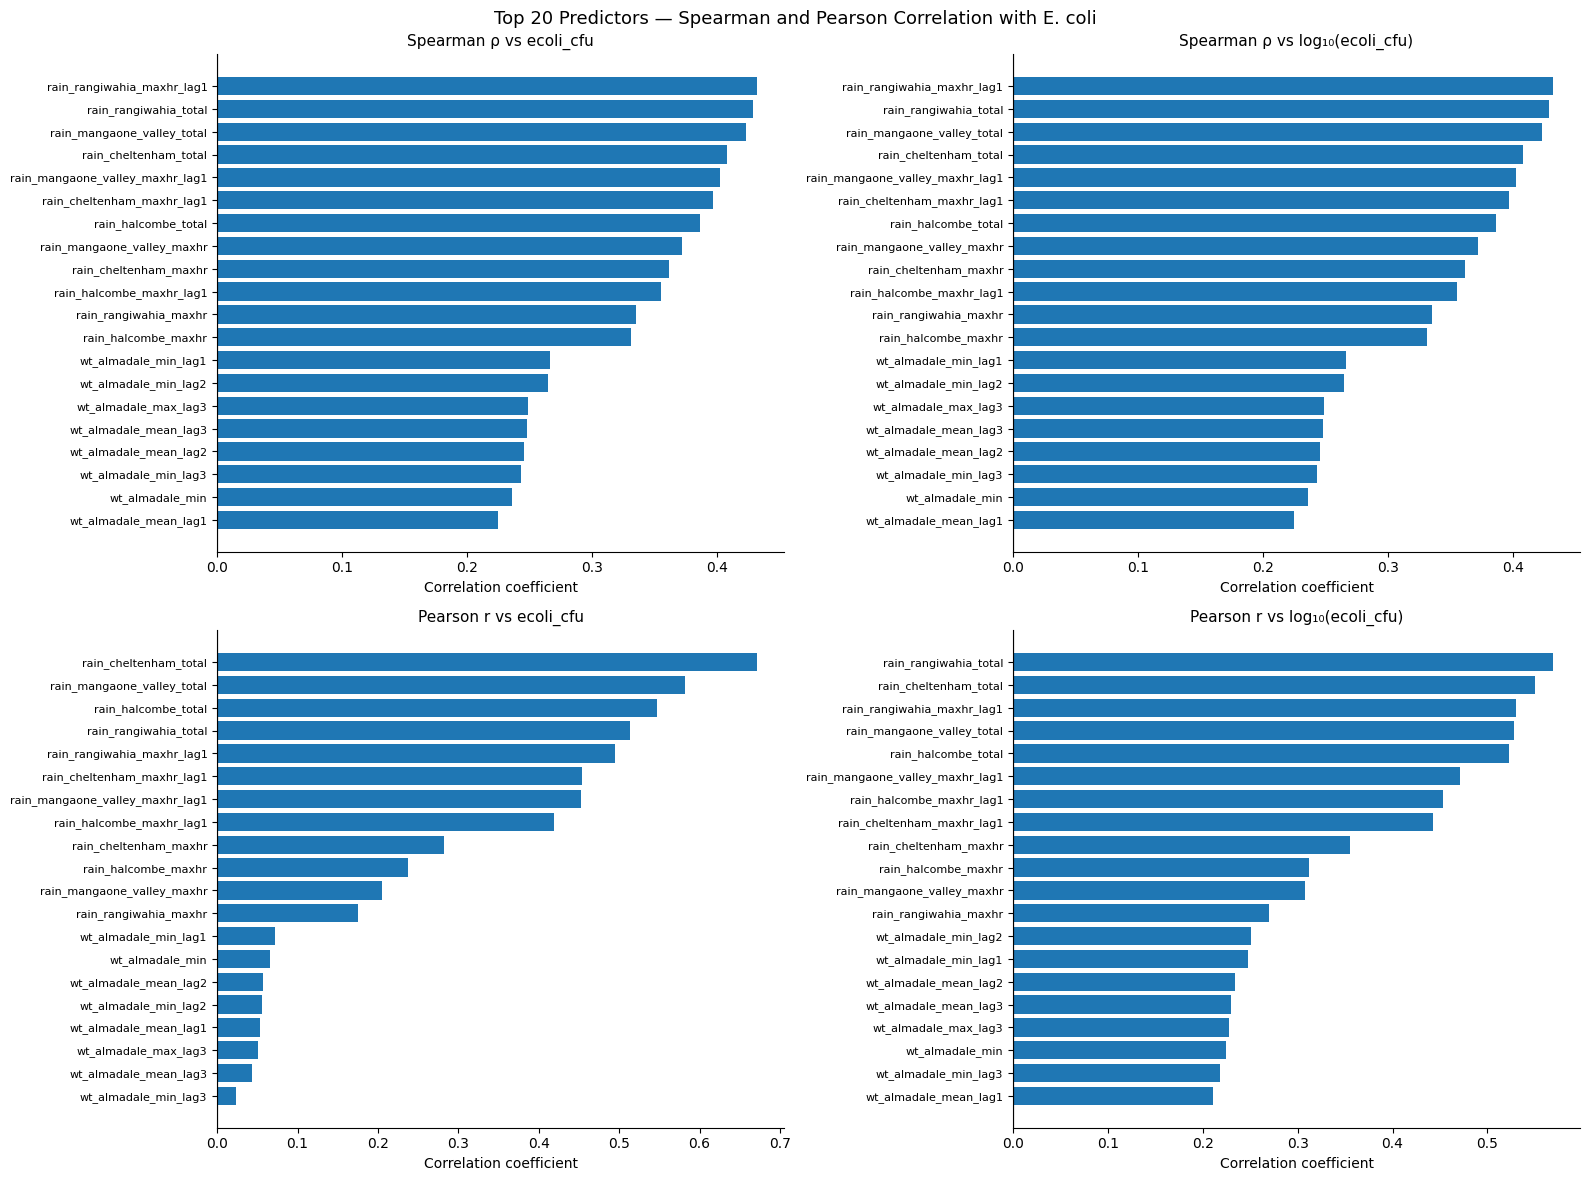

Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/EDA/eda_correlation_ranking.png


In [9]:
# Section 6 — Correlation ranking bar charts
def _bar_colours(series):
    return ['#1f77b4' if v >= 0 else '#ff7f0e' for v in series]

top_n = corr_df.head(TOP_N_CORR)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
panels = [
    (axes[0, 0], 'sp_raw', 'Spearman ρ vs ecoli_cfu'),
    (axes[0, 1], 'sp_log', 'Spearman ρ vs log₁₀(ecoli_cfu)'),
    (axes[1, 0], 'pe_raw', 'Pearson r vs ecoli_cfu'),
    (axes[1, 1], 'pe_log', 'Pearson r vs log₁₀(ecoli_cfu)'),
]

for ax, col, title in panels:
    vals = top_n[col].sort_values()
    ax.barh(vals.index, vals.values, color=_bar_colours(vals.values))
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Correlation coefficient')
    ax.tick_params(axis='y', labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    f'Top {TOP_N_CORR} Predictors — Spearman and Pearson Correlation with E. coli',
    fontsize=13,
)
fig.tight_layout()
fig.savefig(f'{EDA_DIR}/eda_correlation_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {EDA_DIR}/eda_correlation_ranking.png")

In [10]:
# Section 7 — Interactive Spearman correlation heatmap (Plotly)
def _lag_order(cols):
    base = [c for c in cols
            if not any(c.endswith(s) for s in ('_lag1', '_lag2', '_lag3'))
            and c not in ('rain_heavy_count_7d', 'flow_high_count_7d')]
    lag1 = [c for c in cols if c.endswith('_lag1')]
    lag2 = [c for c in cols if c.endswith('_lag2')]
    lag3 = [c for c in cols if c.endswith('_lag3')]
    ante = [c for c in cols if c in ('rain_heavy_count_7d', 'flow_high_count_7d')]
    return base + lag1 + lag2 + lag3 + ante

ordered_cols     = _lag_order(PREDICTORS)
spearman_matrix  = df[ordered_cols].corr(method='spearman')

fig = go.Figure(data=go.Heatmap(
    z=spearman_matrix.values,
    x=ordered_cols,
    y=ordered_cols,
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    hoverongaps=False,
    hovertemplate='%{y} × %{x}<br>ρ = %{z:.3f}<extra></extra>',
))
fig.update_layout(
    title='Spearman correlation matrix — all 46 predictors',
    width=950,
    height=950,
    xaxis=dict(tickfont=dict(size=7), tickangle=45),
    yaxis=dict(tickfont=dict(size=7)),
)
fig.write_html(f'{EDA_DIR}/eda_correlation_heatmap.html')
fig.show()
print(f"Saved: {EDA_DIR}/eda_correlation_heatmap.html")

Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/EDA/eda_correlation_heatmap.html


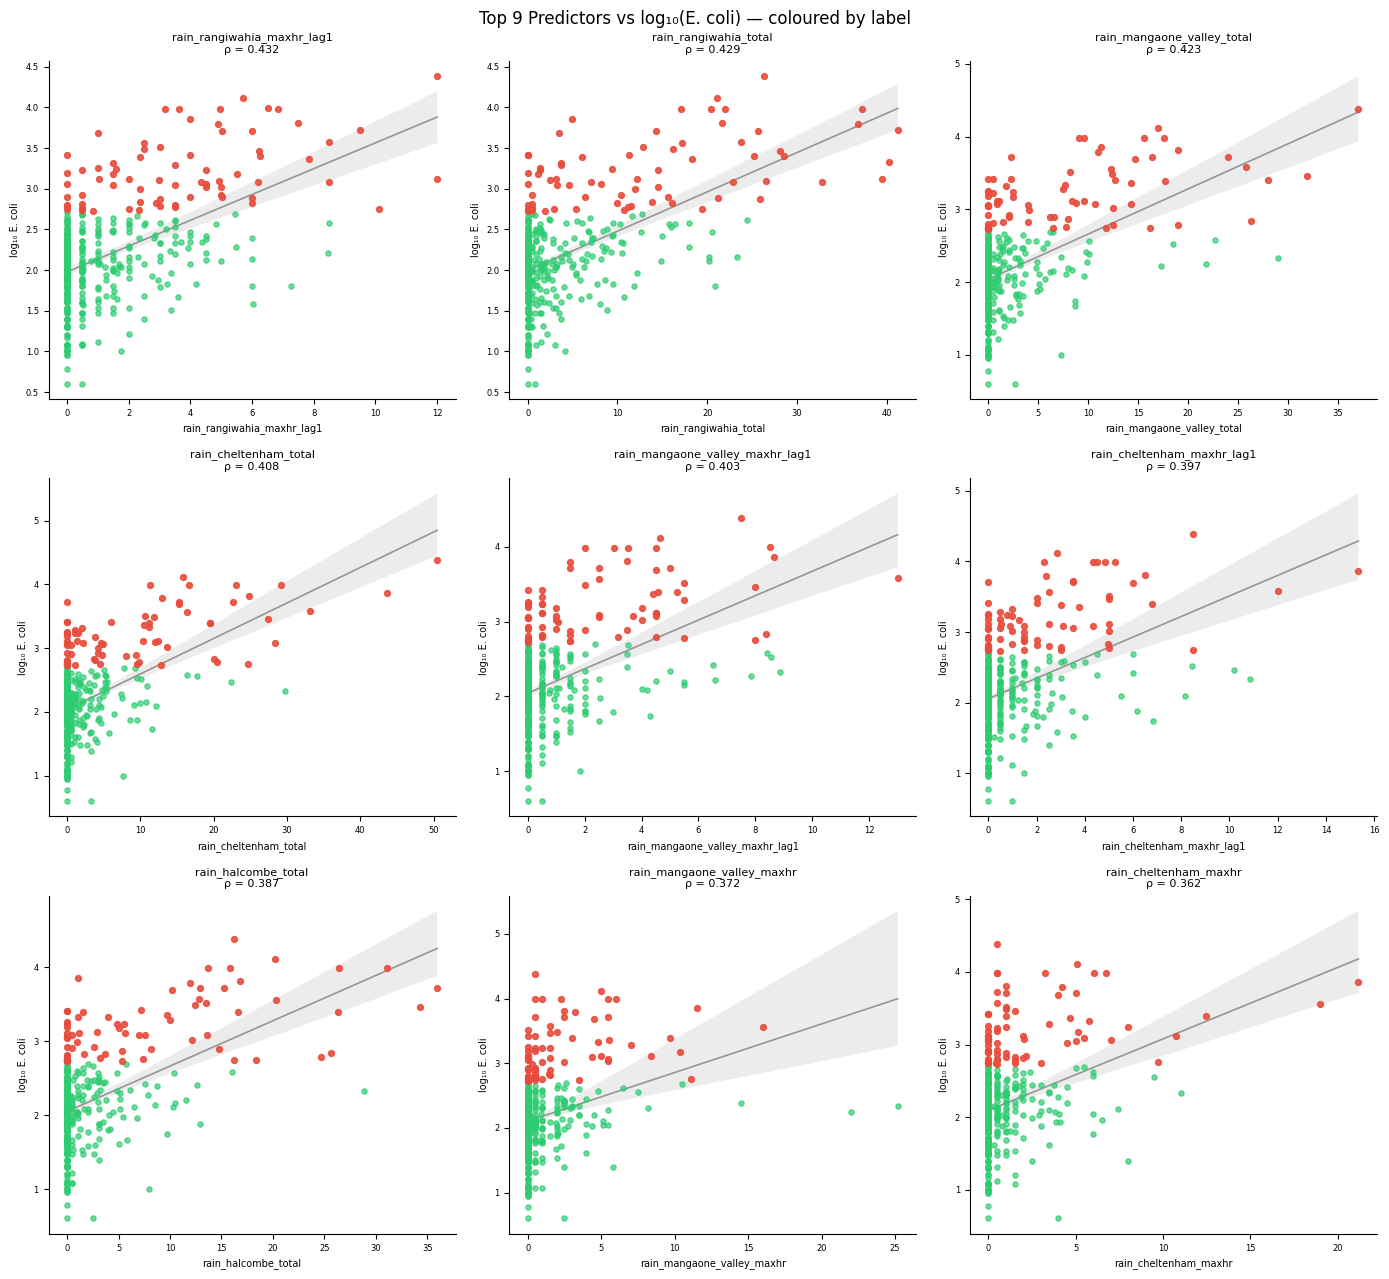

Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/EDA/eda_scatter_top9.png


In [11]:
# Section 8 — Top-predictor scatter plots vs log10(E. coli)
top9 = corr_df.head(TOP_N_SCATTER).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(14, 13))
axes = axes.flatten()

for ax, col in zip(axes, top9):
    rho      = corr_df.loc[col, 'sp_log']
    plot_df  = df[[col, 'log10_ecoli', 'label']].dropna()
    safe_p   = plot_df[plot_df['label'] == 0]
    unsafe_p = plot_df[plot_df['label'] == 1]

    sns.regplot(x=col, y='log10_ecoli', data=plot_df, ax=ax,
                scatter=False,
                line_kws={'color': 'grey', 'linewidth': 1.2, 'alpha': 0.8})
    ax.scatter(safe_p[col],   safe_p['log10_ecoli'],
               color=SAFE_COLOUR,   s=14, alpha=0.7, zorder=5)
    ax.scatter(unsafe_p[col], unsafe_p['log10_ecoli'],
               color=UNSAFE_COLOUR, s=18, alpha=0.9, zorder=6)

    ax.set_title(f'{col}\nρ = {rho:.3f}', fontsize=8)
    ax.set_xlabel(col, fontsize=7)
    ax.set_ylabel('log₁₀ E. coli', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    f'Top {TOP_N_SCATTER} Predictors vs log₁₀(E. coli) — coloured by label',
    fontsize=12,
)
fig.tight_layout()
fig.savefig(f'{EDA_DIR}/eda_scatter_top9.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {EDA_DIR}/eda_scatter_top9.png")

C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




...

C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_22084\3271024857.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




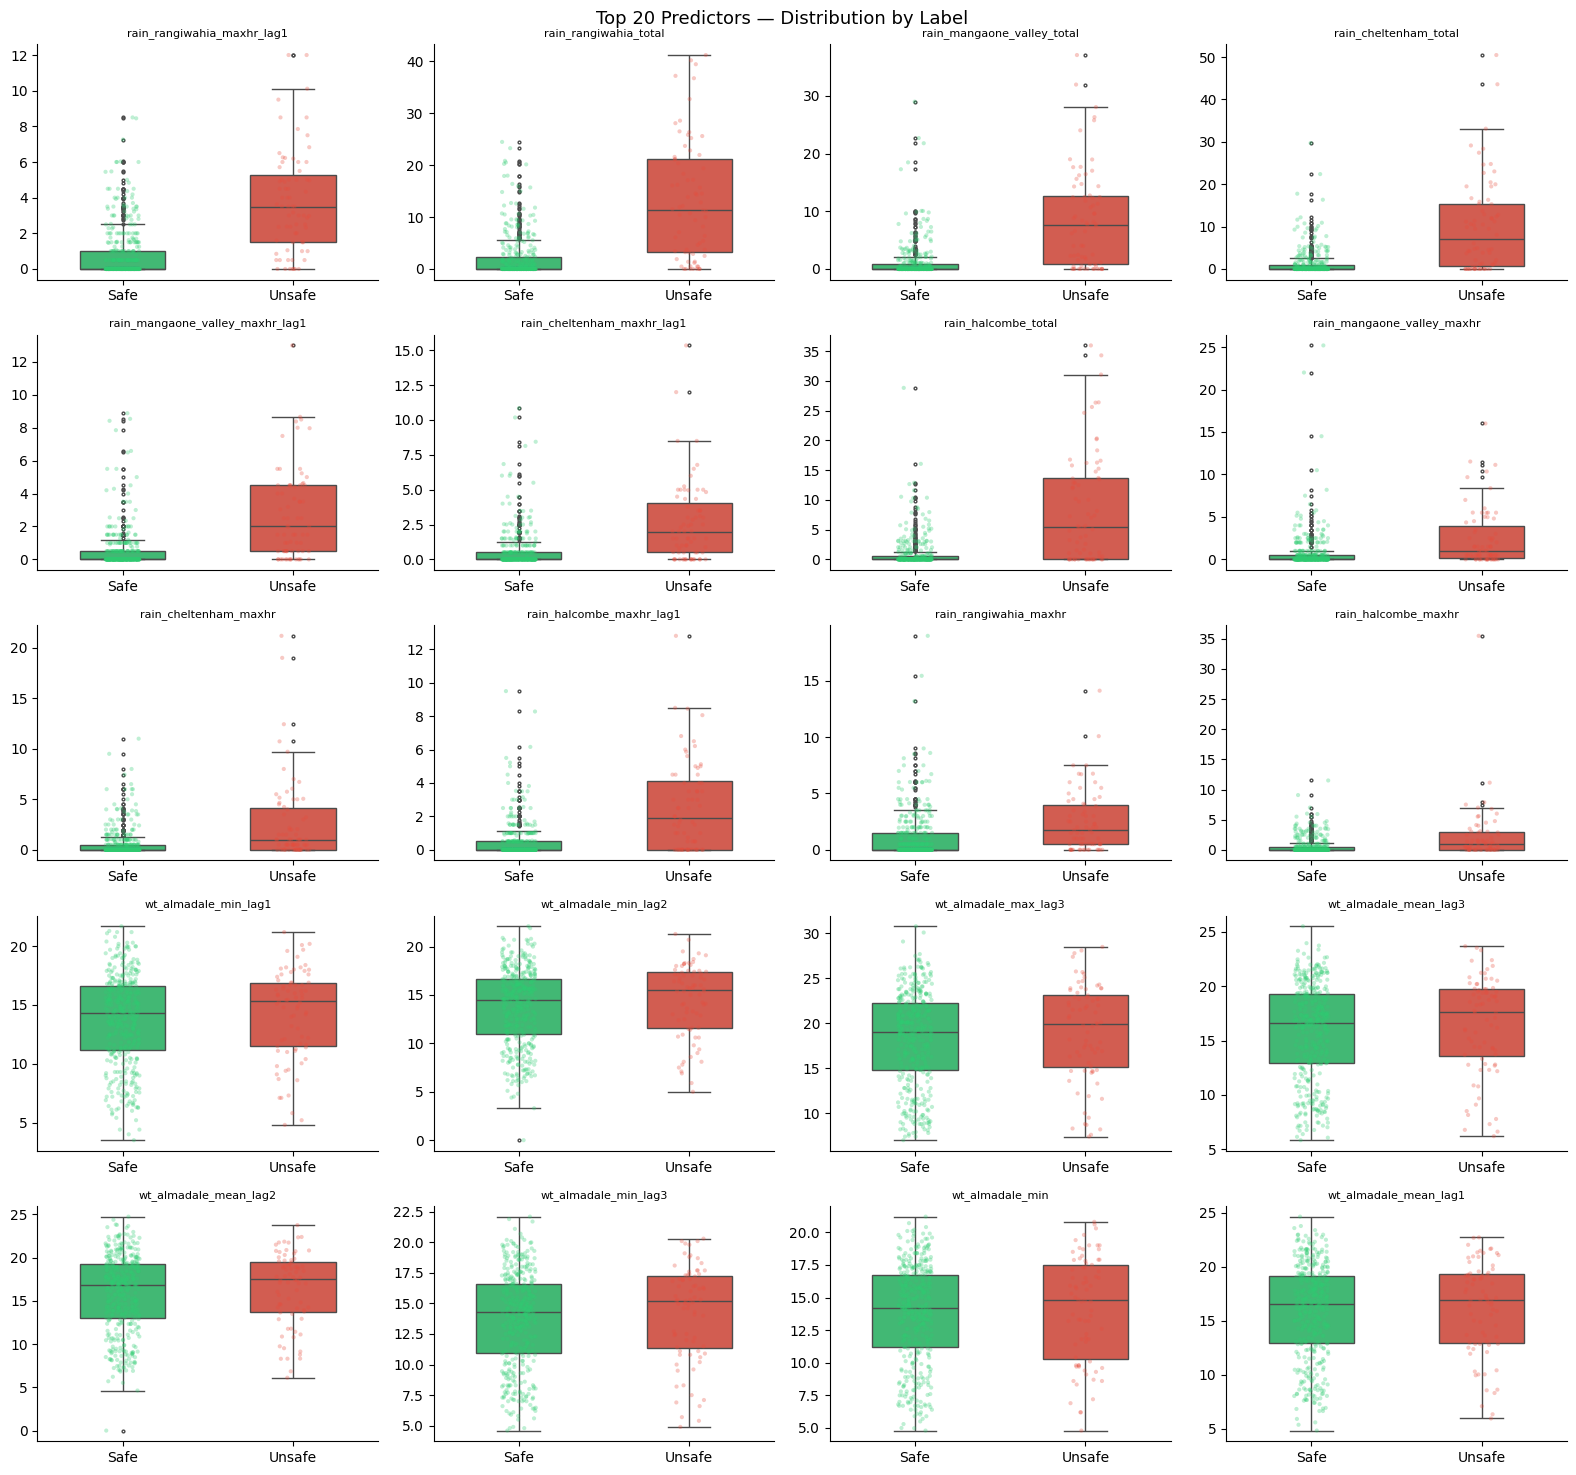

Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/EDA/eda_boxplots_by_label.png


In [12]:
# Section 9 — Predictor boxplots by label (top 20 predictors)
top20_list = corr_df.head(TOP_N_CORR).index.tolist()
label_map  = {0: 'Safe', 1: 'Unsafe'}

n_cols = 4
n_rows = (len(top20_list) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, top20_list):
    plot_df          = df[[col, 'label']].dropna().copy()
    plot_df['Label'] = plot_df['label'].map(label_map)
    palette          = {'Safe': SAFE_COLOUR, 'Unsafe': UNSAFE_COLOUR}

    sns.boxplot(x='Label', y=col, data=plot_df, ax=ax,
                palette=palette, order=['Safe', 'Unsafe'],
                width=0.5, fliersize=2)
    sns.stripplot(x='Label', y=col, data=plot_df, ax=ax,
                  palette=palette, order=['Safe', 'Unsafe'],
                  size=3, alpha=0.30, jitter=True)

    ax.set_title(col, fontsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axes[len(top20_list):]:
    ax.set_visible(False)

fig.suptitle(
    f'Top {TOP_N_CORR} Predictors — Distribution by Label',
    fontsize=13,
)
fig.tight_layout()
fig.savefig(f'{EDA_DIR}/eda_boxplots_by_label.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {EDA_DIR}/eda_boxplots_by_label.png")

In [13]:
# Section 10 — Static gauge location map (Folium)
centre_lat = np.mean([g['lat'] for g in GAUGE_COORDS.values()])
centre_lon = np.mean([g['lon'] for g in GAUGE_COORDS.values()])

m_static = folium.Map(
    location=[centre_lat, centre_lon],
    zoom_start=9,
    tiles='OpenStreetMap',
)

TYPE_COLOUR = {'swim': 'red', 'flow': 'blue', 'rain': 'green', 'wt': 'purple'}
TYPE_RADIUS = {'swim': 14,    'flow': 10,     'rain': 10,    'wt': 10}

for key, g in GAUGE_COORDS.items():
    folium.CircleMarker(
        location=[g['lat'], g['lon']],
        radius=TYPE_RADIUS[g['type']],
        color=TYPE_COLOUR[g['type']],
        fill=True,
        fill_opacity=0.85,
        popup=folium.Popup(
            f"<b>{g['name']}</b><br>Type: {g['type']}",
            max_width=280,
        ),
        tooltip=g['name'],
    ).add_to(m_static)

m_static.save(f'{EDA_DIR}/eda_gauge_map_static.html')
print(f"Saved: {EDA_DIR}/eda_gauge_map_static.html")
m_static

Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/EDA/eda_gauge_map_static.html


In [14]:
# Section 11 — Interactive correlation map (Folium)
# Representative same-day predictor per gauge
GAUGE_PREDICTOR = {
    'flow_almadale':   'flow_almadale_mean',
    'rain_rangiwahia': 'rain_rangiwahia_total',
    'rain_cheltenham': 'rain_cheltenham_total',
    'rain_halcombe':   'rain_halcombe_total',
    'rain_mangaone':   'rain_mangaone_valley_total',
    'wt_almadale':     'wt_almadale_mean',
}

rho_vals = {
    key: corr_df.loc[pred, 'sp_log']
    for key, pred in GAUGE_PREDICTOR.items()
    if pred in corr_df.index
}
max_abs = max(abs(v) for v in rho_vals.values()) or 1.0

m_corr = folium.Map(
    location=[centre_lat, centre_lon],
    zoom_start=9,
    tiles='OpenStreetMap',
)

# Swim site — fixed red marker, no correlation
g = GAUGE_COORDS['swim_site']
folium.CircleMarker(
    location=[g['lat'], g['lon']],
    radius=14,
    color='red',
    fill=True,
    fill_opacity=0.90,
    popup=folium.Popup(f"<b>{g['name']}</b><br>Swim site", max_width=280),
    tooltip=g['name'],
).add_to(m_corr)

# Gauge markers: colour = sign of rho, radius = scaled by |rho|
for key, rho in rho_vals.items():
    g      = GAUGE_COORDS[key]
    colour = '#1f77b4' if rho >= 0 else '#ff7f0e'
    radius = 8 + 16 * (abs(rho) / max_abs)
    pred   = GAUGE_PREDICTOR[key]
    p_val  = corr_df.loc[pred, 'sp_p_log']
    popup_html = (
        f"<b>{g['name']}</b><br>"
        f"Type: {g['type']}<br>"
        f"Predictor: {pred}<br>"
        f"Spearman ρ (vs log₁₀ E. coli): {rho:.3f}<br>"
        f"p-value: {p_val:.4f}"
    )
    folium.CircleMarker(
        location=[g['lat'], g['lon']],
        radius=radius,
        color=colour,
        fill=True,
        fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=320),
        tooltip=f"{g['name']}  ρ={rho:.3f}",
    ).add_to(m_corr)

m_corr.save(f'{EDA_DIR}/eda_gauge_map_correlation.html')
print(f"Saved: {EDA_DIR}/eda_gauge_map_correlation.html")
m_corr

Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/EDA/eda_gauge_map_correlation.html
